In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Lymphoid"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

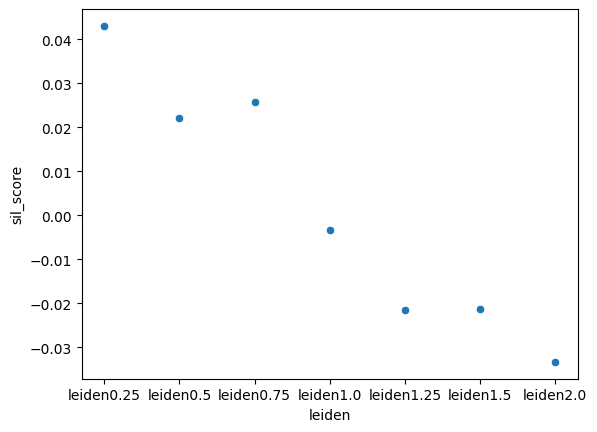

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Use Leiden 0.25, since 0.1 may be too restrictive (only 2 clusters)

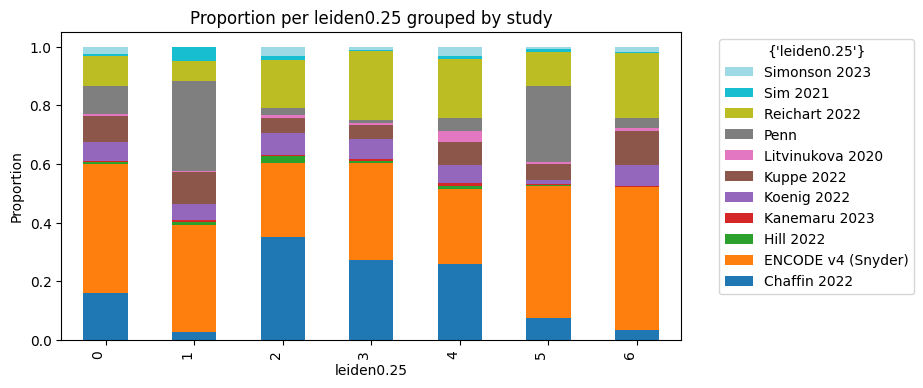

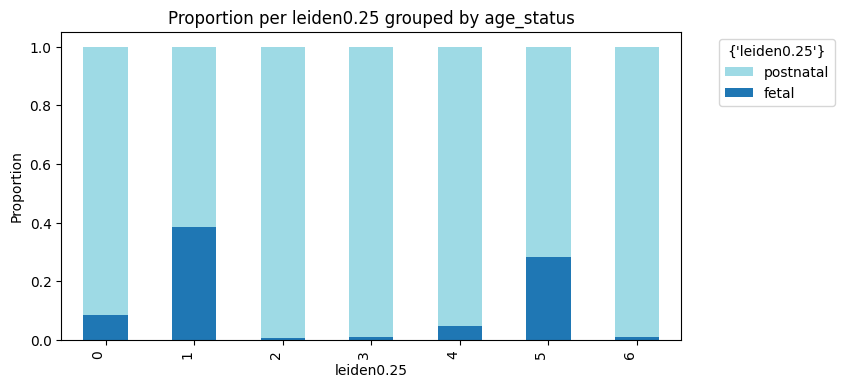

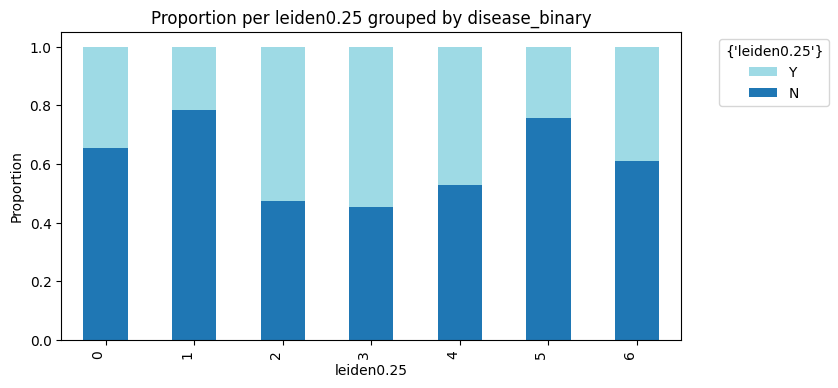

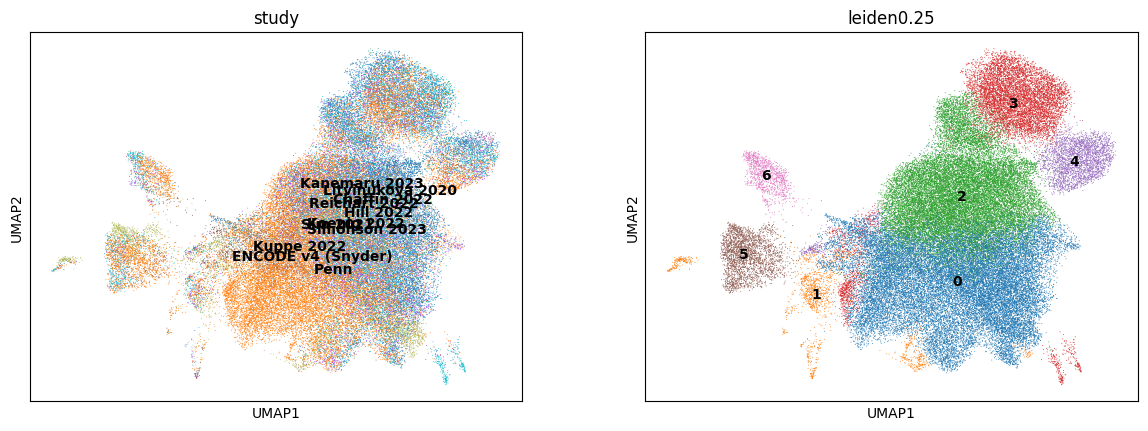

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

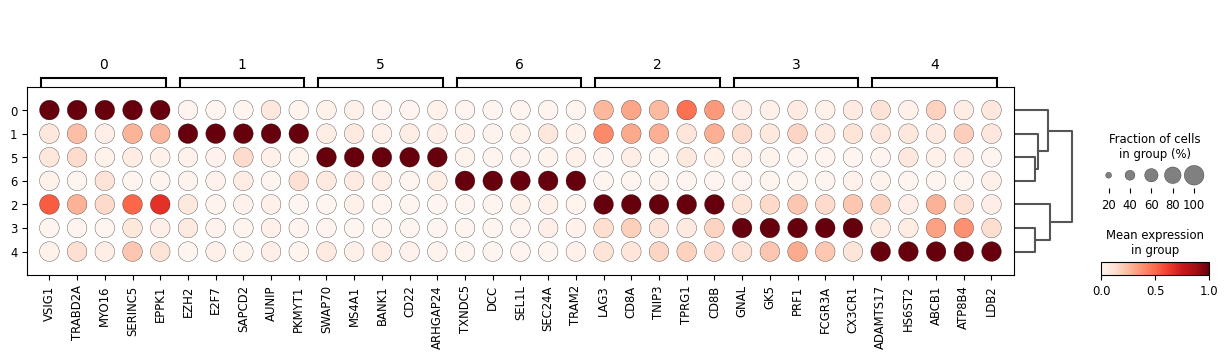

Counter({'0': 27703, '2': 24198, '3': 8694, '4': 3195, '5': 2603, '1': 1594, '6': 1141})


['leiden0.25',
 AnnData object with n_obs × n_vars = 69128 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', '

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

In [7]:
#sc.pl.umap(adata, color = ["KLRC1",],cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

- Cluster 0 are helper T cells (IL7R/CD28/CD40LG)
- Cluster 1 are cycling lymphoid cells (EZH2/MCM2/E2F2)
- Cluster 2 are cytotoxic T-cells  (CD8A/CD8B/FAS)
- Cluster 3 are NK cells (PRF1/GZMB/CX3CR1)
- Cluster 4 are NK cells (KLRC1/KLRC2/KLRF2)
- Cluster 5 are B cells (MS4A1/PAX5/BANK1)
- Cluster 6 are plasma cells (MZB1/SDC1/XBP1)

In [8]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "T_helper",
     "1": "Cycling",
     "2": "T_cytotoxic",
     "3": "NK_1",
     "4": "NK_2",
     "5": "B",
     "6": "B_plasma",
    }
)

In [9]:
subcluster_order = ["T_helper", "Cycling", "T_cytotoxic", "NK_1", "NK_2", "B", "B_plasma"]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "T_helper": "#1f77b4",     # blue
    "Cycling": "#D3D3D3",    # light gray
    "T_cytotoxic": "#ff7f0e",  # orange
    "NK_1": "#2ca02c",          # green
    "NK_2": "#17becf",          # cyan
    "B": "#9467bd",              # purple
    "B_plasma": "#e377c2"       # pink
}

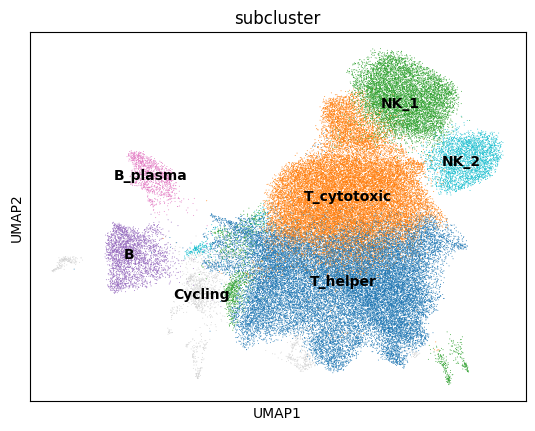

In [10]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig("Lymphoid_subclustered.pdf", bbox_inches="tight")

- Cluster 0 are helper T cells (IL7R/CD28/CD40LG)
- Cluster 1 are cycling B cells (EZH2/MCM2/E2F2)
- Cluster 2 are cytotoxic T-cells  (CD8A/CD8B/FAS)
- Cluster 3 are NK cells (PRF1/GZMB/CX3CR1)
- Cluster 4 are NK cells (KLRC1/KLRC2/KLRF2)
- Cluster 5 are B cells (MS4A1/PAX5/BANK1)
- Cluster 6 are plasma cells (MZB1/SDC1/XBP1)

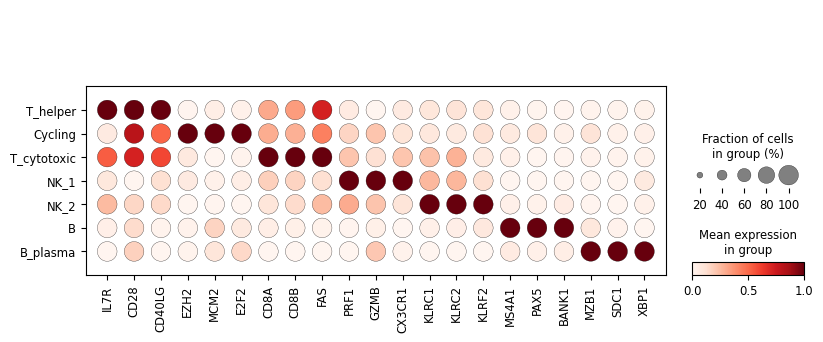

In [11]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["IL7R", "CD28", "CD40LG",
                                     "EZH2", "MCM2", "E2F2", 
                                     "CD8A", "CD8B", "FAS",
                                     "PRF1", "GZMB", "CX3CR1",
                                     "KLRC1", "KLRC2", "KLRF2",
                                     "MS4A1", "PAX5", "BANK1",
                                     "MZB1", "SDC1", "XBP1"], groupby = "subcluster", layer="scvi_normalized",
                  standard_scale='var', show=False)
    plt.savefig("Lymphoid_subclustered_dotplot.pdf", bbox_inches="tight")

In [12]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

    subcluster  count  proportion
0     T_helper  27703    0.400749
1  T_cytotoxic  24198    0.350046
2         NK_1   8694    0.125767
3         NK_2   3195    0.046219
4            B   2603    0.037655
5      Cycling   1594    0.023059
6     B_plasma   1141    0.016506
